# Importar librerías

In [1]:
import sys
from pathlib import Path

# Ajustar el path del proyecto para importar el módulo desde src/
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent

if not (project_root / "src").exists():
    raise FileNotFoundError("No se encontró la carpeta 'src' en el árbol de directorios.")

# Importante: insertar la raíz del proyecto, no la carpeta src.
sys.path.insert(0, str(project_root.resolve()))
print("project_root:", project_root)
print("sys.path[0]:", sys.path[0])

project_root: c:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project
sys.path[0]: C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project


# Librerías de simulación y análisis

In [2]:
import pandas as pd
pd.set_option('display.max_columns', 50)
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord

from src.simulacion_cumulo import (
    ClusterSimulationConfig,
    OpenClusterSimulator,
)
from src.vector_director import run_cluster_analysis_from_dataframe
from src.proper_motion_simulator import simulate_proper_motions_from_3d_velocity
from src.utils import (
    show_cluster_validation_products_icrs,
    correct_gaia_proper_motions,
    plot_pm_vectors_on_sky,
    galactic_lb_to_unit_vectors,
)

In [11]:
from dataclasses import replace
from typing import Optional
from joblib import Parallel, delayed
from tqdm.auto import tqdm

import numpy as np
import pandas as pd


def simulate_and_measure_apex_error_at_position(
    base_config: ClusterSimulationConfig,
    center_ra_deg: float,
    center_dec_deg: float,
    cluster_id: str,
    group_value: str = "1",
    seed: Optional[int] = None,
    metric_key: str = "rms_pole_residual_initial_deg",
) -> dict:
    """
    Simula un cúmulo sintético en una posición dada del cielo y calcula
    la métrica de error del ápex.
    """

    config = replace(
        base_config,
        center_ra_deg=center_ra_deg,
        center_dec_deg=center_dec_deg,
        center_l_deg=None,
        center_b_deg=None,
        seed=seed,
    )

    try:
        simulator = OpenClusterSimulator(config)
        catalog = simulator.simulate()

        catalog["cluster_id"] = cluster_id
        catalog["grupo"] = group_value

        result = run_cluster_analysis_from_dataframe(
            df=catalog,
            cluster_id=cluster_id,
            group_col="grupo",
            ra_col="ra",
            dec_col="dec",
            pmra_col="pmra",
            pmdec_col="pmdec",
            parallax_col="parallax",
            cluster_col="cluster_id",
            weight_fill_value=1,
        )

        summary = result.get("summary", {})
        metric_value = summary.get(metric_key, np.nan)

        return {
            "center_ra_deg": center_ra_deg,
            "center_dec_deg": center_dec_deg,
            "cluster_id": cluster_id,
            "seed": seed,
            metric_key: metric_value,
            "status": "ok",
            "error_message": "",
        }

    except Exception as exc:
        return {
            "center_ra_deg": center_ra_deg,
            "center_dec_deg": center_dec_deg,
            "cluster_id": cluster_id,
            "seed": seed,
            metric_key: np.nan,
            "status": "failed",
            "error_message": repr(exc),
        }


def make_ra_dec_grid(
    ra_step_deg: float = 10.0,
    dec_step_deg: float = 10.0,
    dec_min_deg: float = -80.0,
    dec_max_deg: float = 80.0,
) -> pd.DataFrame:
    """
    Construye una malla regular en RA y Dec.
    """

    ra_values = np.arange(0.0, 360.0, ra_step_deg)
    dec_values = np.arange(dec_min_deg, dec_max_deg + dec_step_deg, dec_step_deg)

    rows = []

    for dec in dec_values:
        for ra in ra_values:
            rows.append(
                {
                    "center_ra_deg": float(ra),
                    "center_dec_deg": float(dec),
                }
            )

    return pd.DataFrame(rows)


def run_apex_error_sky_grid_parallel(
    base_config: ClusterSimulationConfig,
    ra_step_deg: float = 10.0,
    dec_step_deg: float = 10.0,
    dec_min_deg: float = -80.0,
    dec_max_deg: float = 80.0,
    n_realizations_per_position: int = 1,
    base_seed: int = 42,
    metric_key: str = "rms_pole_residual_initial_deg",
    n_jobs: int = 2,
    show_progress: bool = True,
) -> pd.DataFrame:
    """
    Ejecuta una malla RA-Dec en paralelo.

    Parameters
    ----------
    n_jobs : int
        Número de procesos paralelos.
        En computador básico recomiendo 2.
        Si tienes 4 núcleos, puedes probar 3.
        Evita usar todos los núcleos si el análisis consume mucha memoria.
    """

    grid = make_ra_dec_grid(
        ra_step_deg=ra_step_deg,
        dec_step_deg=dec_step_deg,
        dec_min_deg=dec_min_deg,
        dec_max_deg=dec_max_deg,
    )

    tasks = []
    counter = 0

    for _, row in grid.iterrows():
        ra = float(row["center_ra_deg"])
        dec = float(row["center_dec_deg"])

        for realization_id in range(n_realizations_per_position):
            counter += 1

            seed = base_seed + counter

            cluster_id = (
                f"grid_ra_{ra:06.1f}_dec_{dec:+06.1f}"
                f"_mc_{realization_id:03d}"
            )

            tasks.append(
                {
                    "center_ra_deg": ra,
                    "center_dec_deg": dec,
                    "cluster_id": cluster_id,
                    "seed": seed,
                    "realization_id": realization_id,
                }
            )

    iterator = tqdm(tasks, total=len(tasks)) if show_progress else tasks

    rows = Parallel(
        n_jobs=n_jobs,
        backend="loky",
        prefer="processes",
        verbose=0,
    )(
        delayed(simulate_and_measure_apex_error_at_position)(
            base_config=base_config,
            center_ra_deg=task["center_ra_deg"],
            center_dec_deg=task["center_dec_deg"],
            cluster_id=task["cluster_id"],
            group_value="1",
            seed=task["seed"],
            metric_key=metric_key,
        )
        for task in iterator
    )

    results = pd.DataFrame(rows)

    # Recuperar realization_id desde tasks
    task_df = pd.DataFrame(tasks)
    results = results.merge(
        task_df[
            [
                "center_ra_deg",
                "center_dec_deg",
                "cluster_id",
                "seed",
                "realization_id",
            ]
        ],
        on=[
            "center_ra_deg",
            "center_dec_deg",
            "cluster_id",
            "seed",
        ],
        how="left",
    )

    return results

In [ ]:
GAIA_LIKE_PM_ERROR = dict(
    pmra_error_distribution="log10_triangular",
    pmra_error_log10_left=-3.0,
    pmra_error_log10_mode=-1.7,
    pmra_error_log10_right=0.0,

    # Relación empírica:
    # pmdec_error ≈ 0.7 * pmra_error
    pm_error_slope=0.7,

    # Correlación entre perturbaciones de pmra y pmdec.
    # Puedes cambiar este valor si quieres explorar otros casos.
    pmra_pmdec_corr=0.2,

    # Dispersión alrededor de la pendiente 0.7.
    # Déjalo en 0.0 si quieres una línea exacta.
    pm_error_slope_logscatter=0.08,
)
config_hyades_error_alld = ClusterSimulationConfig(
    n_members=455,

    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Error en paralaje
    parallax_error_mas=0.03,

    # Errores Gaia-like en movimientos propios
    **GAIA_LIKE_PM_ERROR,

    # Dispersión física, no error observacional
    speed_sigma_kms=5.0,
)

In [ ]:
results_grid = run_apex_error_sky_grid_parallel(
    base_config=config_hyades_error_alld,
    ra_step_deg=5.0,
    dec_step_deg=5.0,
    dec_min_deg=-80.0,
    dec_max_deg=80.0,
    n_realizations_per_position=1,
    base_seed=42,
    metric_key="rms_pole_residual_initial_deg",

    # Para computador básico
    n_jobs=4,

    show_progress=True,
)

  0%|          | 0/612 [00:00<?, ?it/s]

In [14]:
grid_summary = (
    results_grid
    .groupby(["center_ra_deg", "center_dec_deg"], as_index=False)
    .agg(
        metric_mean=("rms_pole_residual_initial_deg", "mean"),
        metric_median=("rms_pole_residual_initial_deg", "median"),
        metric_std=("rms_pole_residual_initial_deg", "std"),
        metric_min=("rms_pole_residual_initial_deg", "min"),
        metric_max=("rms_pole_residual_initial_deg", "max"),
        n_total=("rms_pole_residual_initial_deg", "size"),
        n_valid=("rms_pole_residual_initial_deg", lambda x: np.isfinite(x).sum()),
    )
)

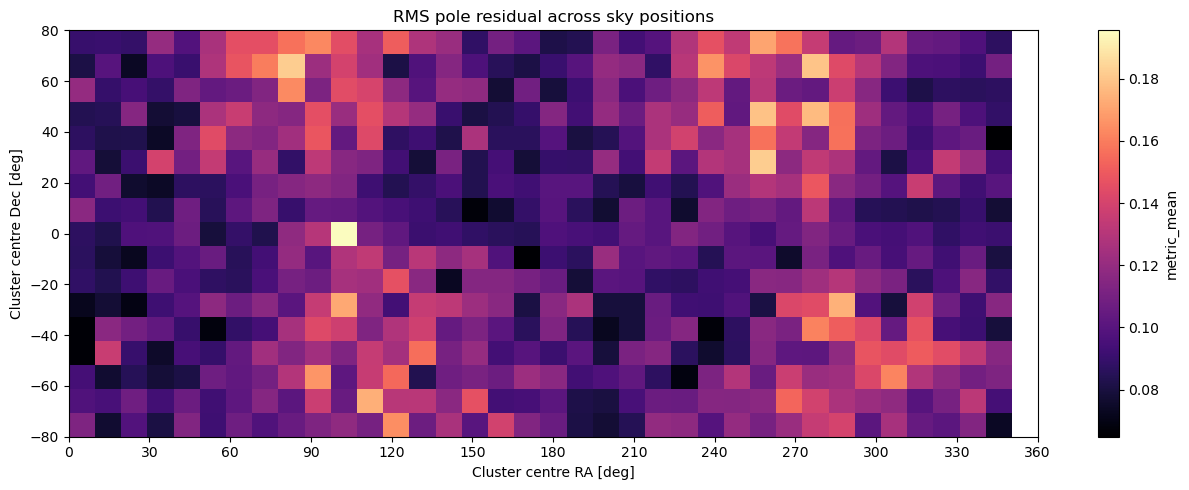

(<Figure size 1300x500 with 2 Axes>,
 <Axes: title={'center': 'RMS pole residual across sky positions'}, xlabel='Cluster centre RA [deg]', ylabel='Cluster centre Dec [deg]'>)

In [15]:
plot_apex_error_grid(
    grid_summary,
    value_col="metric_mean",
    title="RMS pole residual across sky positions",
    cmap="magma",
)

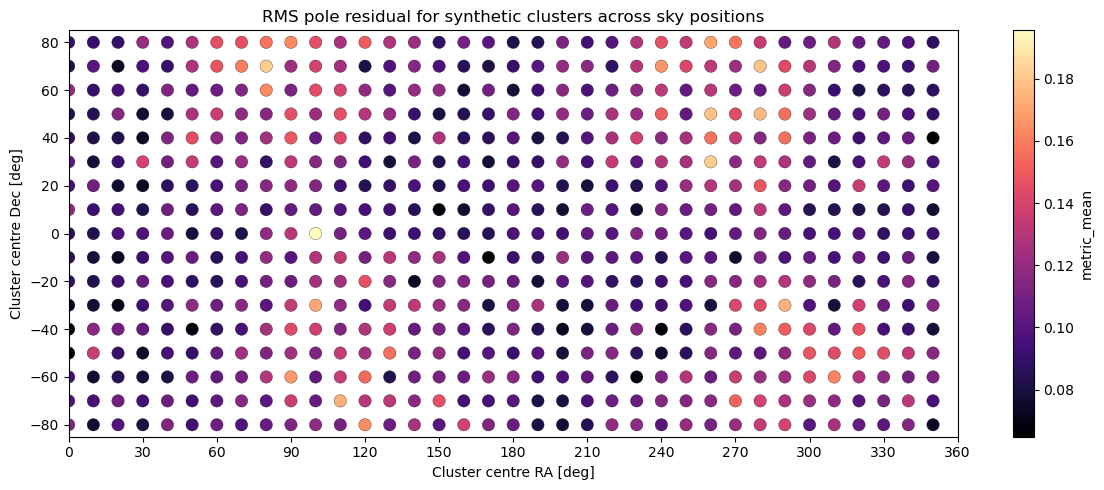

(<Figure size 1200x500 with 2 Axes>,
 <Axes: title={'center': 'RMS pole residual for synthetic clusters across sky positions'}, xlabel='Cluster centre RA [deg]', ylabel='Cluster centre Dec [deg]'>)

In [16]:
plot_apex_error_scatter(
    grid_summary,
    value_col="metric_mean",
    title="RMS pole residual for synthetic clusters across sky positions",
    cmap="magma",
)

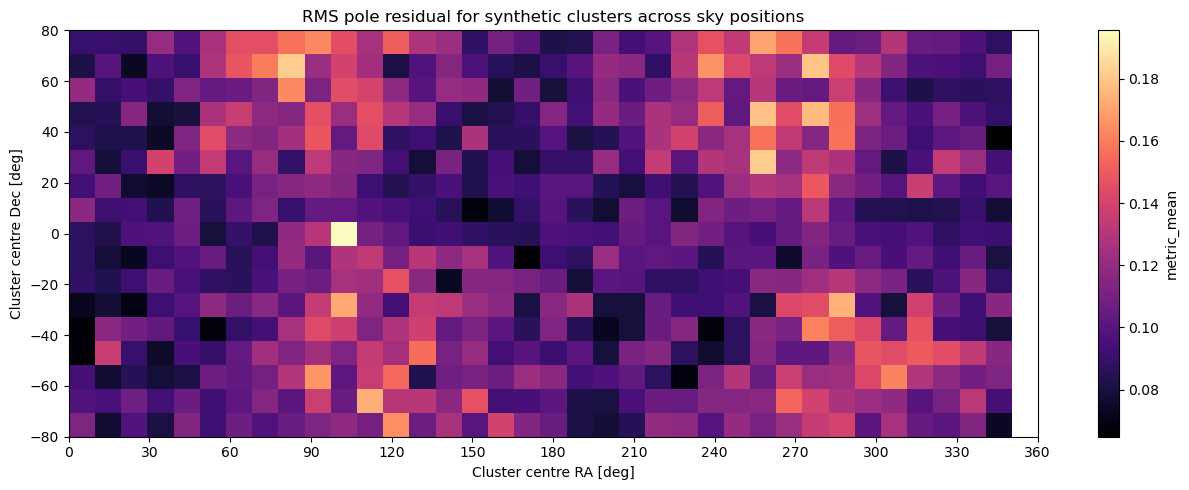

(<Figure size 1300x500 with 2 Axes>,
 <Axes: title={'center': 'RMS pole residual for synthetic clusters across sky positions'}, xlabel='Cluster centre RA [deg]', ylabel='Cluster centre Dec [deg]'>)

In [ ]:
results_grid.to_csv(
    "hyades_synthetic_error_alld_sky_grid_raw.csv",
    index=False,
)

grid_summary.to_csv(
    "hyades_synthetic_error_alld_sky_grid_summary.csv",
    index=False,
)

In [ ]:
# results_grid = run_apex_error_sky_grid(
#     base_config=config_hyades_error_alld,
#     ra_step_deg=10.0,
#     dec_step_deg=10.0,
#     dec_min_deg=-80.0,
#     dec_max_deg=80.0,
#     n_realizations_per_position=10,
#     base_seed=42,
#     metric_key="rms_pole_residual_initial_deg",
#     verbose=True,
# )